<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


Este bloque de código es para reconocer en modo local la tarjeta Nvidia con CUDA con `tensorflow`, por si se quiere reproducir el entrenamiento.

El notebook está hecho de forma que sea puedan cargar los modelos ya entrenados por medio de `tensorflow.keras.models.load_model()`.

In [1]:
import os
import sys
import glob
# Construct the path to the nvidia packages within the virtual environment
site_packages = os.path.join(sys.prefix, 'lib', f'python{sys.version_info.major}.{sys.version_info.minor}', 'site-packages')
nvidia_base_path = os.path.join(site_packages, 'nvidia')
# Find all 'lib' directories inside the nvidia package and add them to LD_LIBRARY_PATH
nvidia_lib_dirs = glob.glob(os.path.join(nvidia_base_path, '*', 'lib'))
if nvidia_lib_dirs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_lib_dirs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')

import tensorflow as tf
# 1. Verify TensorFlow can physically see the GPU hardware
print("GPUs Found: ", tf.config.list_physical_devices('GPU'))
# 2. Check if it was built with CUDA support
print("Built with CUDA: ", tf.test.is_built_with_cuda())

I0000 00:00:1780957010.683047 4133460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780957010.708245 4133460 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780957011.260157 4133460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs Found:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA:  True


Dependencias:

In [2]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models 
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

from tensorflow.keras.preprocessing.text import text_to_word_sequence

# utilizadades de keras para armado de los modelos
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense, GRU
from keras.models import Model, Sequential

# descargar de textos.info
import urllib.request
# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

# para guardar y levantar diccionarios
import pickle

# Datos

Utilizo el libro de Marco Aurelio "Meditaciones" como corpus. Es un libro relativamente corto, por lo que el entrenamiento no es inviablemente largo.

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/marco-aurelio/meditaciones-2/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()


Defino los diccionarios y los guardo con `pickle` para posterior uso al levantar los modelos.

**Está comentada la parte de la celda utilizada durante entrenamiento y en uso la parte de la celda utilziada cuando se levanta el modelo con `keras.models.load_model`, el cual requiere de utilizar el mismo diccionario de encode/decode.**

In [3]:
max_context_size = 1000

#---------------------------------------------------------------------------------------------------------
# PARTE DE LA CELDA A CORRER SI SE QUIERE RE-ENTRENAR EL MODELO ##########################################
#---------------------------------------------------------------------------------------------------------
# chars_vocab = set(article_text)

# # Construimos los dicionarios que asignan índices a caracteres y viceversa.
# # El diccionario `char2idx` servirá como tokenizador.
# char2idx = {k: v for v,k in enumerate(chars_vocab)}
# idx2char = {v: k for k,v in char2idx.items()}

# # Guardado de diccionarios
# with open("char2idx.pkl", "wb") as file:
#     pickle.dump(char2idx, file)
# with open("idx2char.pkl", "wb") as file:
#     pickle.dump(idx2char, file)

# # tokenizamos el texto completo
# tokenized_text = [char2idx[ch] for ch in article_text]
#---------------------------------------------------------------------------------------------------------
##########################################################################################################
#---------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------
# PARTE DE LA CELDA A CORRER SI SE UTILIZA UN MODELO YA ENTRENADO ########################################
#---------------------------------------------------------------------------------------------------------
with open("char2idx.pkl", "rb") as file:
    char2idx = pickle.load(file)
with open("idx2char.pkl", "rb") as file:
    idx2char = pickle.load(file)
#---------------------------------------------------------------------------------------------------------
##########################################################################################################
#---------------------------------------------------------------------------------------------------------



### División en train y test

In [4]:
#---------------------------------------------------------------------------------------------------------
# CELDA A CORRER SI SE QUIERE RE-ENTRENAR EL MODELO ######################################################
#---------------------------------------------------------------------------------------------------------
# p_test = 0.1 # proporción utilizada para test
# num_test = int(np.ceil(len(tokenized_text)*p_test/max_context_size)) # cantidad de secuencia a utilizar en test

# # dividimos en train y test
# train_text = tokenized_text[:-num_test*max_context_size]
# train_tokenized_sentences = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]
# X_train = np.array(train_tokenized_sentences[:-1])
# y_train = np.array(train_tokenized_sentences[1:])

# test_text = tokenized_text[-num_test*max_context_size:]
# test_tokenized_sentences = [test_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_test)]
#---------------------------------------------------------------------------------------------------------
##########################################################################################################
#---------------------------------------------------------------------------------------------------------

# Modelos

Definimos el callback para calcular la perplejidad.

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data
      
      self.history_ppl = history_ppl

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          # self.model.save("my_model.keras")
          # print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True



Definimos modelos a comparar:

In [ ]:
#---------------------------------------------------------------------------------------------------------
# CELDA A CORRER SI SE QUIERE RE-ENTRENAR EL MODELO ######################################################
#---------------------------------------------------------------------------------------------------------
# vocab_size = len(chars_vocab)
# models = {}

# models['SimpleRNN'] = Sequential(name='SimpleRNN')
# models['SimpleRNN'].add(Input(shape=(None,1)))
# models['SimpleRNN'].add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot")))
# models['SimpleRNN'].add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
# models['SimpleRNN'].add(Dense(vocab_size, activation='softmax'))
# models['SimpleRNN'].compile(loss=SparseCategoricalCrossentropy(), optimizer='rmsprop')
# models['SimpleRNN'].summary()

# models['LSTM'] = Sequential(name='LSTM')
# models['LSTM'].add(Input(shape=(None,1)))
# models['LSTM'].add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot")))
# models['LSTM'].add(LSTM(200, return_sequences=True))
# models['LSTM'].add(Dropout(0.1))
# models['LSTM'].add(LSTM(200, return_sequences=True)) # La última capa LSTM no lleva return_sequences
# models['LSTM'].add(Dense(32, activation='relu'))
# models['LSTM'].add(Dense(vocab_size, activation='softmax'))
# models['LSTM'].compile(loss=SparseCategoricalCrossentropy(), optimizer='adam')
# models['LSTM'].summary()

# models['GRU'] = Sequential(name='GRU')
# models['GRU'].add(Input(shape=(None,1)))
# models['GRU'].add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot")))
# models['GRU'].add(GRU(200, return_sequences=True))
# models['GRU'].add(Dropout(0.1))
# models['GRU'].add(GRU(200, return_sequences=True)) # La última capa LSTM no lleva return_sequences
# models['GRU'].add(Dense(32, activation='relu'))
# models['GRU'].add(Dense(vocab_size, activation='softmax'))
# models['GRU'].compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
# models['GRU'].summary()
#---------------------------------------------------------------------------------------------------------
##########################################################################################################
#---------------------------------------------------------------------------------------------------------

I0000 00:00:1780953531.746507 3841899 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19140 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 60)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        52,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 60)       │        12,060 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,260 (251.02 KB)

 Trainable params: 64,260 (251.02 KB)

...

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 60)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       157,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, None, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 200)      │       241,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, None, 32)       │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, None, 60)       │         1,980 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,812 (1.55 MB)

 Trainable params: 406,812 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamos los modelos:

In [ ]:
#---------------------------------------------------------------------------------------------------------
# CELDA A CORRER SI SE QUIERE RE-ENTRENAR EL MODELO ######################################################
#---------------------------------------------------------------------------------------------------------
# hist_ppl = {}
# for model_key in models.keys():
#     hist_ppl_model = []
#     hist = models[model_key].fit(X_train, y_train, epochs=20, callbacks=[PplCallback(test_tokenized_sentences, hist_ppl_model)], batch_size=256)
#     hist_ppl[model_key] = hist_ppl_model
#---------------------------------------------------------------------------------------------------------
##########################################################################################################
#---------------------------------------------------------------------------------------------------------

Epoch 1/20


I0000 00:00:1780953553.608438 3842433 service.cc:153] XLA service 0x8a53df50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780953553.608472 3842433 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780953554.576303 3842433 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1780953554.592233 3842433 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1780953554.700680 3842433 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780953554.905012 3842433 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_1_simple_rnn_1_while_body_43409_grad_43622_const_0__.20.clone.clone.clone.clone.clone.clone
I0000 00:00:1780953555.490068 384243

  2/979 ━━━━━━━━━━━━━━━━━━━━ 1:06 68ms/step - loss: 4.0981  

I0000 00:00:1780953560.125530 3842433 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


978/979 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 2.4320

W0000 00:00:1780953624.419654 3842433 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1780953624.721666 3842433 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_1_simple_rnn_1_while_body_43409_grad_43622_const_0__.20.clone.clone.clone.clone.clone.clone
I0000 00:00:1780953625.161075 3842433 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780953625.400316 3843773 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1780953625.408019 3842433 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hi

979/979 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 2.4318

I0000 00:00:1780953634.393815 3842433 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780953634.504250 3844013 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1780953634.575467 3844001 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 52 bytes spill stores, 52 bytes spill loads

I0000 00:00:1780953644.493254 3842432 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780953644.676


 mean perplexity: 11.36325454711914 

Saved new model!
979/979 ━━━━━━━━━━━━━━━━━━━━ 103s 89ms/step - loss: 2.1783
Epoch 2/20
979/979 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.8813
 mean perplexity: 9.254552841186523 

Saved new model!
979/979 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - loss: 1.8406
Epoch 3/20
979/979 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.7563
 mean perplexity: 9.83796501159668 

979/979 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - loss: 1.7393
Epoch 4/20
979/979 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.7004
 mean perplexity: 9.797751426696777 

979/979 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - loss: 1.6915
Epoch 5/20
978/979 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.6695
 mean perplexity: 9.844292640686035 

979/979 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - loss: 1.6634
Epoch 6/20
978/979 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.6484
 mean perplexity: 9.668172836303711 

979/979 ━━━━━━━━━━━━━━━━━━━━ 64s 66ms/step - loss: 1.6441
Epoch 7/20
978/979 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/s

El tiempo de entrenamiento por step de los modelos en una GPU RTX 3090 es del orden de:
- SimpleRNN: 60-70ms
- LSTM: 115-125ms
- GRU: 100-110ms

<!-- En este caso se tienen XXX steps/epoch y 20 epochs, por lo que los tiempos totales de entrenamiento son del orden de:
- SimpleRNN: 14-16.5min
- LSTM: 27-29.5min
- GRU: 23.5-26min -->

Guardado de los modelos ya entrandos y el diccionario con el historial de la perplejidad durante entrenamiento:

In [ ]:
#---------------------------------------------------------------------------------------------------------
# CELDA A CORRER SI SE RE-ENTRENO EL MODELO ##############################################################
#---------------------------------------------------------------------------------------------------------
# for model_key in models.keys():
#     models[model_key].save(f"{model_key}.keras")

# with open("hist_ppl.pkl", "wb") as file:
#     pickle.dump(hist_ppl, file)
#---------------------------------------------------------------------------------------------------------
##########################################################################################################
#---------------------------------------------------------------------------------------------------------


Si queremos recuperar los modelos guardados (y también el historial de perplejidad), corremos:

In [7]:
#---------------------------------------------------------------------------------------------------------
# CELDA A CORRER SI SE UTILIZA UN MODELO YA ENTRENADO ####################################################
#---------------------------------------------------------------------------------------------------------
# Levanto los modelos
models_keys = ["SimpleRNN", "LSTM", "GRU"]
models = {}
for model_key in models_keys:
    models[model_key] = keras.models.load_model(f"{model_key}.keras", compile=False)

# Levanto el historial de perplexity durante entrenamiento
with open("hist_ppl.pkl", "rb") as file:
    hist_ppl = pickle.load(file)
#---------------------------------------------------------------------------------------------------------
##########################################################################################################
#---------------------------------------------------------------------------------------------------------

Graficamos el historial de perplejidad:

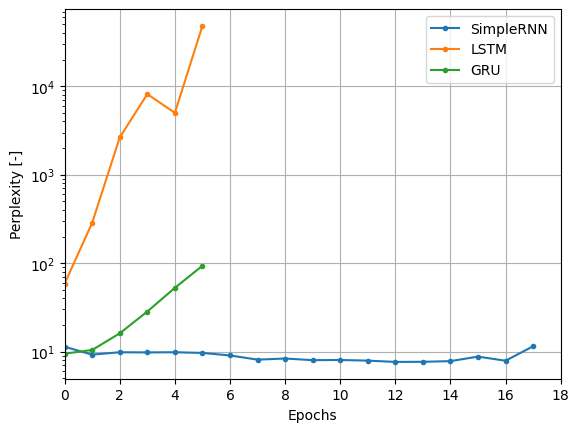

In [8]:
fig, ax = plt.subplots(1,1)
for model_key in models.keys():
    ax.plot(range(len(hist_ppl[model_key])), hist_ppl[model_key], label=model_key, marker='.')

plt.yscale('log')
plt.ylabel("Perplexity [-]")
plt.xlabel("Epochs")
plt.xlim(0,np.max([len(hist_ppl_model) for hist_ppl_model in hist_ppl.values()]))
plt.grid()
plt.legend()
plt.show()

Definimos las funciones para hacer greedy search y beam search a partir de funciones dadas por los profesores. Se realizaron algunos ajustes leves.

In [9]:
def generate_seq(model, seed_text, max_length, n_words, char2idx, idx2char):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text


In [10]:
# funcionalidades para hacer encoding y decoding
from scipy.special import softmax

def encode(text, char2idx, max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq, idx2char):
    return ''.join([idx2char[ch] for ch in seq])

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,char2idx, temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input, char2idx)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

Veamos que sucede si realizamos predicciones con greedy search. Se da cada modelo una secuencia inicial, y luego se hace al modelo predecir 2 secuencias, una a partir de la original y otra a partir de la original más la 1er predicción.

In [11]:
input_text='el hombre debe '
print(f"Secuencia semilla: {input_text}")

for model_key in models.keys():
    print(f"Predicción modelo {model_key}:")
    out = input_text
    for _ in range(2):
        # out = generate_seq(models[model_key], input_text, max_length=max_context_size, n_words=30, char2idx=char2idx, idx2char=idx2char)
        out = generate_seq(models[model_key], out, max_length=max_context_size, n_words=30, char2idx=char2idx, idx2char=idx2char)
        print(out)


Secuencia semilla: el hombre debe 
Predicción modelo SimpleRNN:


I0000 00:00:1780957136.216308 4134003 service.cc:153] XLA service 0x11c26600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780957136.216322 4134003 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780957136.898355 4134003 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780957136.971587 4134003 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780957140.857638 4134003 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


el hombre debe una vida de la misma se debe a
el hombre debe una vida de la misma se debe a ser una vida de la misma se d
Predicción modelo LSTM:
el hombre debe lla a spercación de razón a lo
el hombre debe lla a spercación de razón a los mismos progigos ni en la nat
Predicción modelo GRU:
el hombre debe perfectamente consigo misma, s
el hombre debe perfectamente consigo misma, sin duda en la constancia en el


Observamos que:
- `SimpleRNN` no da algo con sentido y comienza a repetirse.
- `LSTM` entrega una secuencia de palabras que no existen ("lla a spercación") en la primer predicción, y luego "progigos" en la segunda predicción.
- `GRU` entrega predicciones que tienen sentido debido a que el corpus se expresa de una forma particular, por lo que podríamos decir que es el "ganador" de esta comparativa.

Probemos ahora las predicciones con beam search:

In [24]:
input_text='el hombre debe '
print(f"Secuencia semilla: {input_text}")

for model_key in models.keys():
    print(f"Predicción modelo {model_key}:")
    out = input_text
    for _ in range(3):
        # out = beam_search(models[model_key], num_beams=10, num_words=30, input=input_text, char2idx=char2idx)
        out = beam_search(models[model_key], num_beams=10, num_words=30, input=out, char2idx=char2idx)
        out = decode(out[0], idx2char)
        print(out)


Secuencia semilla: el hombre debe 
Predicción modelo SimpleRNN:
el hombre debe tiempo de la naturaleza de la 
el hombre debe tiempo de la naturaleza de la naturaleza de la naturaleza de
el hombre debe tiempo de la naturaleza de la naturaleza de la naturaleza de la naturaleza de la naturalez
Predicción modelo LSTM:
el hombre debe una adquilicante de una misma 
el hombre debe una adquilicante de una misma naturaleza universal es natura
el hombre debe una adquilicante de una misma naturaleza universal es naturaleza, la constitución
a manera
Predicción modelo GRU:
el hombre debe hacer otra cosa alguna de los 
el hombre debe hacer otra cosa alguna de los hombres de la naturaleza del u
el hombre debe hacer otra cosa alguna de los hombres de la naturaleza del universo, con todo lo que se ha


Observamos que:
- `SimpleRNN` vuelve a diverger repitiendo palabras.
- `LSTM` vuelve a poner palabras inventadas.
- `GRU` nuevamente expresa algo factible a partir del corpus, en este caso es una oración cuyo sentido se entiende plenamente.

Es probable que el mal comportamiento de `LSTM` sea producto de la alta perplejidad con la que termina su entrenamiento.

`SimpleRNN` prueba ser demasiado simple al no tener una memoria, generando que se empiece a repetir.

En este caso, `GRU` es claramente el mejor modelo.